<a href="https://colab.research.google.com/github/Thangapandi1611/ml-safety-project/blob/main/week5/Testing_Vehicle_model_on_different_types_of_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#Packages load
import torch
import torch.nn as nn

from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd
from PIL import Image
import os

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#Loading
test_fog = "/content/drive/MyDrive/MLS_DATA/test-fog"
test_night="/content/drive/MyDrive/MLS_DATA/test-night"
test_town="/content/drive/MyDrive/MLS_DATA/test-town-01"
model_path = "/content/drive/MyDrive/MLS_DATA/Vehicle_model.pth"

In [5]:
#Image Transform
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [6]:
class CarlaDataset(Dataset):

    def __init__(self, data_path, label_column, transform=None):

        self.data_path = data_path
        self.transform = transform

        self.labels = pd.read_csv(
            os.path.join(data_path, "labels.csv")
        )

        self.label_column = label_column

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        row = self.labels.iloc[idx]

        frame = str(row['frame']).zfill(6)

        img_path = os.path.join(
            self.data_path,
            "rgb-front",
            f"{frame}.jpg"
        )

        image = Image.open(img_path).convert("RGB")

        label = int(row[self.label_column])

        if self.transform:
            image = self.transform(image)

        return image, label

In [7]:
#Evaluation function
def evaluate_model(model_file, label_column,test_path):

    # Create dataset
    val_dataset = CarlaDataset(
        test_path,
        label_column=label_column,
        transform=transform
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=32,
        shuffle=False
    )

    # Create model
    model = models.resnet18(pretrained=True)

    model.fc = nn.Linear(
        model.fc.in_features,
        1
    )

    # Load weights
    model.load_state_dict(
        torch.load(model_file, map_location=device)
    )

    model = model.to(device)

    model.eval()

    # Prediction lists
    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels_batch in val_loader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.sigmoid(outputs)

            preds = (probs > 0.5).int()

            all_preds.extend(preds.cpu().numpy())

            all_labels.extend(labels_batch.numpy())


    # Flatten predictions
    all_preds = [p[0] for p in all_preds]

    # Metrics
    cm = confusion_matrix(all_labels, all_preds)
    accuracy = accuracy_score(all_labels, all_preds)

    precision = precision_score(all_labels, all_preds)

    recall = recall_score(all_labels, all_preds)

    f1 = f1_score(all_labels, all_preds)

    return accuracy, precision, recall, f1, cm

In [8]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cpu


In [9]:
#Testing On differeent Types of Test Data
Evaluation_FOG=evaluate_model(model_path,"has_vehicle",test_fog)
Evaluation_night=evaluate_model(model_path,"has_vehicle",test_night)
Evaluation_town=evaluate_model(model_path,"has_vehicle",test_town)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 150MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other th

In [10]:
#CREATE COMPARISON TABLE
results = pd.DataFrame({

    "Test": [
        "Foggy Data",
        "Night Data",
        "Town Data"
    ],

    "Accuracy": [
        Evaluation_FOG[0],
        Evaluation_night[0],
        Evaluation_town[0]
    ],

    "Precision": [
        Evaluation_FOG[1],
        Evaluation_night[1],
        Evaluation_town[1]
    ],

    "Recall": [
        Evaluation_FOG[2],
        Evaluation_night[2],
        Evaluation_town[2]
    ],

    "F1-score": [
        Evaluation_FOG[3],
        Evaluation_night[3],
        Evaluation_town[3]
    ],

    "Cm": [
        Evaluation_FOG[4],
        Evaluation_night[4],
        Evaluation_town[4]
    ]
})

results

,Test,Accuracy,Precision,Recall,F1-score,Cm
0,Foggy Data,0.360833,0.997942,0.174147,0.296545,"[[814, 1], [2300, 485]]"
1,Night Data,0.429722,0.989305,0.265709,0.418907,"[[807, 8], [2045, 740]]"
2,Town Data,0.816389,0.920384,0.758140,0.831421,"[[1309, 141], [520, 1630]]"


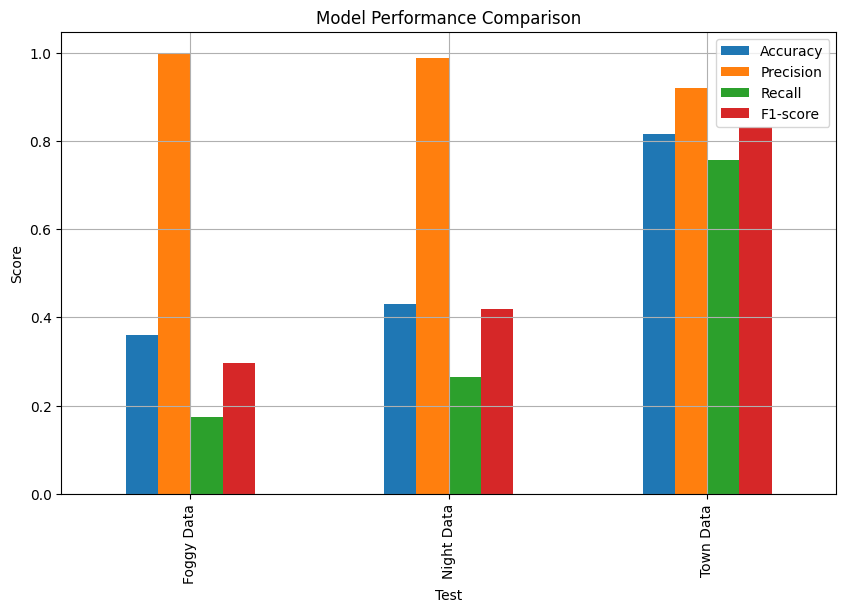

In [11]:
#PLOT COMPARSION
results.set_index("Test").plot(
    kind='bar',
    figsize=(10,6)
)

plt.ylabel("Score")
plt.title("Model Performance Comparison")

plt.grid(True)

plt.show()

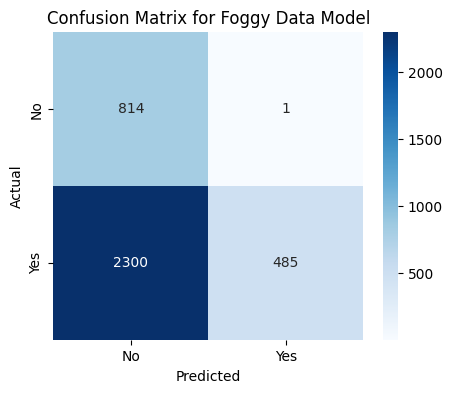

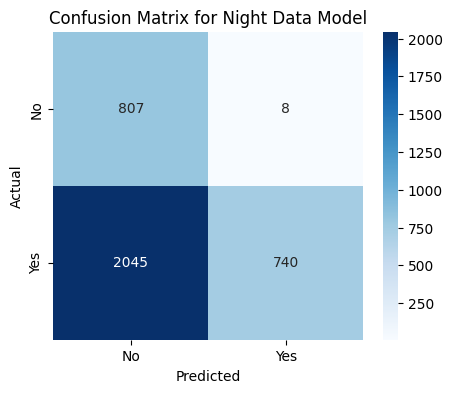

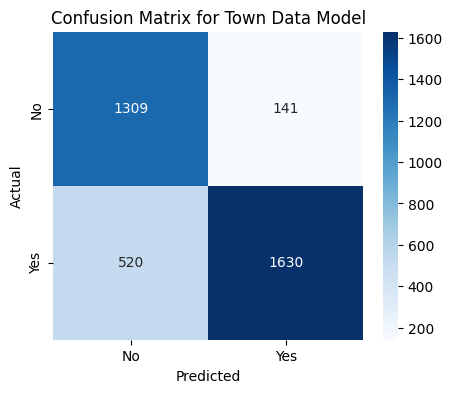

In [12]:
#Plotting Confusion Matrices

def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['No', 'Yes'],
        yticklabels=['No', 'Yes']
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

# Plot confusion matrix for each model
for index, row in results.iterrows():
    model_name = row['Test']
    cm = row['Cm']
    plot_confusion_matrix(cm, f"Confusion Matrix for {model_name} Model")